#  <center> Problem Set 2 <center>
<center> 3.C01/3.C51, 7.C01/7.C51, 10.C01/10.C51, 20.C01/20.C51<center>

<b>Name: Zach Pracher </b>

<b>Kerberos id: zachprac </b>

### Download required data & install packages

In [1]:
! wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/dna_binding.csv
!wget https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/cell_segmentation_jpeg.tar.gz
!tar -xf cell_segmentation_jpeg.tar.gz

--2025-04-14 02:07:40--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/dna_binding.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1408340 (1.3M) [text/plain]
Saving to: ‘dna_binding.csv’

dna_binding.csv     100%[===================>]   1.34M  --.-KB/s    in 0.05s   

2025-04-14 02:07:40 (28.4 MB/s) - ‘dna_binding.csv’ saved [1408340/1408340]

--2025-04-14 02:07:40--  https://raw.githubusercontent.com/coleygroup/ML4MolEng/main/psets/ps2-bio/data/cell_segmentation_jpeg.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiti

In [2]:
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

from torchvision.io import read_image
import torchvision.transforms as transforms
from torchvision.models import vgg16
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.utils import shuffle
import glob

import os
import PIL
from PIL import Image
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import imageio
from skimage import io, color



matplotlib.rcParams.update({'font.size': 15})
matplotlib.rc('lines', linewidth=3, color='g')
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams['axes.linewidth'] = 2.0
matplotlib.rcParams["xtick.major.size"] = 6
matplotlib.rcParams["ytick.major.size"] = 6
matplotlib.rcParams["ytick.major.width"] = 2
matplotlib.rcParams["xtick.major.width"] = 2
matplotlib.rcParams['text.usetex'] = False

## <center>Problem 1: Predicting DNA Binding Sites</center>

In [3]:
df = pd.read_csv("./dna_binding.csv")

sequences = df.seq.values
y = df.bind.values

print(f"Number of Sequences: {len(sequences)} of length {len(sequences[0])}")
print(f"Number of ")

Number of Sequences: 12904 of length 101
Number of 


### 1.1 (20 points) Build Datasets and DataLoaders in PyTorch

One-hot encode DNA sequence data.

In [4]:
def SeqEnc(sequences):
    '''
    A function to one-hot encode DNA sequences

    Args:
        sequences (list): list of DNA sequences

    Returns:
        np.array: array with shape (N,C,4) where N is the number of sequences
        and C is the sequence length
    '''
    ################ Code #################
    DNA = np.array(["A", "C", "G", "T"])
    all_seqs = []
    for seq in sequences:
      onehot = np.array([DNA == nuc for nuc in seq]).astype(int)
      all_seqs.append(onehot)
    return np.array(all_seqs)

# Apply the encoding
feat_seqs_all = SeqEnc(sequences)
    ################ Code #################

Implement your dataset class that takes in your data.

In [5]:
# Generate dataset
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.Tensor(np.array(X))  # store X as a pytorch Tensor
        self.y = torch.Tensor(np.array(y))  # store y as a pytorch Tensor
        self.len=len(self.X)                # number of samples in the data

    def __getitem__(self, index):
        # your implementation here:
        return self.X[index], self.y[index]

    def __len__(self):
        return self.len

Define your Datasets and DataLoaders.

In [6]:
# Define dataset
# Split train and validation
X_train_full, X_test, y_train_full, y_test = train_test_split(feat_seqs_all, y, test_size=0.2, random_state=0)

# Split 10% of training data off for convergence testing
X_sub_train, X_val, y_subtrain, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=0)

#Build Dataset
train_data = SequenceDataset(X_sub_train, y_subtrain) # fill in code here
val_data = SequenceDataset(X_val, y_val) # fill in code here
test_data = SequenceDataset(X_test, y_test) # fill in code here

# Build DataLoader
batch_size=256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

What is the benefit of batching your data into mini-batches versus using the entire dataset to optimize the model all at once?

In [7]:
################ Answer #################



################ Answer #################

Mini-batching enables us to spend less time occupying the GPUs, which frequently have limited storage. This also enables parallelization across GPUs for rapid train-test cycles. Each minibatch also has a unique loss landscape, so it helps us decrease probability of getting trapped in a local minimum of the overall batch.

### 1.2 (20 points) Build an LSTM-based binding classifier

The following example will help familiarize you with the LSTM.

In [8]:
# Define a LSTM module
lstm_model = nn.LSTM(input_size=4, hidden_size=16, num_layers=1, batch_first=True, bidirectional=True).to("cpu") # "cpu" is the device id

# Send your batch to a GPU
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to("cpu")
y_batch = y_batch.to("cpu")

# Propagate your batch into your model
lstm_out, (ht, ct) = lstm_model(X_batch)
print(f"LSTM Output Shape: {lstm_out.shape}\n Hidden State Shape: {ht.shape}\n Cell state of the last element: {ct.shape}")

# You can play with hyperparameters to see how your output change

LSTM Output Shape: torch.Size([256, 101, 32])
 Hidden State Shape: torch.Size([2, 256, 16])
 Cell state of the last element: torch.Size([2, 256, 16])


Now build your LSTM-based classifier as a nn.Module.

In [9]:
class LSTMseq(torch.nn.Module) :
    def __init__(self, input_dim, hidden_dim) :
        super().__init__()

        # Define a LSTM module
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=1, batch_first=True, bidirectional=True)
        # Define a MLP regressor

        self.mlp = nn.Sequential(nn.Linear(hidden_dim, hidden_dim),
                                 nn.Tanh(),
                                 nn.Linear(hidden_dim, hidden_dim),
                                 nn.Tanh(),
                                 nn.Linear(hidden_dim, 1)

        )
        # Define a sigmoid transform
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        # Apply LSTM
        lstm_out, (ht, ct) = self.lstm(x)
        # Pass output into a MLP
        mlp_out = self.mlp(ht[1])
        # Transform output into probabilites
        sig_out = self.sigmoid(mlp_out)
        # Return probabilities
        proba = sig_out

        return proba

In [10]:
# Test your ouput on a batch
clf = LSTMseq(input_dim=4, hidden_dim=16).to('cpu')
print(clf(X_batch).shape)

torch.Size([256, 1])


### 1.3 (20 points) Implement functions for training and testing

The training and validation loops and evaluation function.

In [11]:
def train(model, dataloader, optimizer, device):

    '''
    A function to train on the entire dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        optimizer (torch.optim.Optimizer): Optimizer object to interface gradient calculation and optimization
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    batch_loss = []
    model.train() # Set model to training mode

    for batch in dataloader:
        seq, label = batch
        seq = seq.to(device)
        label = label.to(device)

        # train your model on each batch here

        ## Make prediction, find loss
        pred = model(seq).squeeze(1)
        #print(f"Prediction shape: {pred.shape}\t Label Shape: {label.shape}")
        loss = nn.functional.binary_cross_entropy(pred, label)
        batch_loss.append(loss.item()) # Record loss

        ## Update parameters with Adam
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    mean_loss = sum(batch_loss) / len(batch_loss)

    return mean_loss


def validate(model, dataloader, device):

    '''
    A function to validate on the validation dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the validation data
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    val_loss = []
    model.eval() # Set model to evaluation mode
    with torch.no_grad():
        for batch in dataloader:
            seq, label = batch
            seq = seq.to(device)
            label = label.to(device)

            # validate your model on each batch here
            ## Make prediction, find loss
            pred = model(seq).squeeze(1)
            loss = nn.functional.binary_cross_entropy(pred, label)
            val_loss.append(loss.item()) # Record loss

    mean_loss = sum(val_loss) / len(val_loss)

    return mean_loss

def evaluate(model, dataloader, device):

    '''
    A function to return the classification probabilities and true labels (for evaluation).

    Args:
        model (torch.nn.Module): your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        device (str): Your device

    Returns:
        (np.array, np.array): true labels, predicted probabilities
    '''

    pred_prob = []
    labels = []
    batch_num = 0
    with torch.no_grad():
        model.eval()
        for batch in dataloader:
            epoch_loss = []
            seq, label = batch

            seq = seq.to(device)
            label = label.to(device)

            # evaluate your model here
            probs = model(seq) # Returns the probability
            pred_prob.extend(probs.cpu().detach().numpy()) # So we don't concatenate a bunch of tensors we later need to detach from the GPU
            labels.extend(label.cpu().detach().numpy())

            # Progress tracker
            print(f"Batch {batch_num} completed.")
            batch_num += 1

    end_labels = np.array(labels)
    end_probs = np.array(pred_prob)
    return end_labels, end_probs

In [12]:
device = 'cuda:0'
model = LSTMseq(4, 16).to(device)

optimizer = torch.optim.Adam(list(model.parameters()), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', verbose=True, factor=0.5)

val_loss_curve = []
train_loss_curve = []

# Use tqdm for progress bar
tqdm_progress =  tqdm(range(500), desc="Progress")

for epoch in tqdm_progress:
    # Compute train your model on training data
    epoch_loss = train(model, train_loader, optimizer,  device=device)

    # Validate your on validation data
    val_loss = validate(model, val_loader, device=device)

    # Record train and loss performance
    train_loss_curve.append(epoch_loss)
    val_loss_curve.append(val_loss)

    # The learning rate scheduler record the validation loss
    scheduler.step(val_loss)
    tqdm_progress.set_postfix(train_loss=f'{epoch_loss:.3f}', val_loss=f'{val_loss:.3f}', refresh=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Progress: 100%|██████████| 500/500 [01:46<00:00,  4.67it/s, train_loss=0.121, val_loss=0.338]


Plot train and validation loss functions.

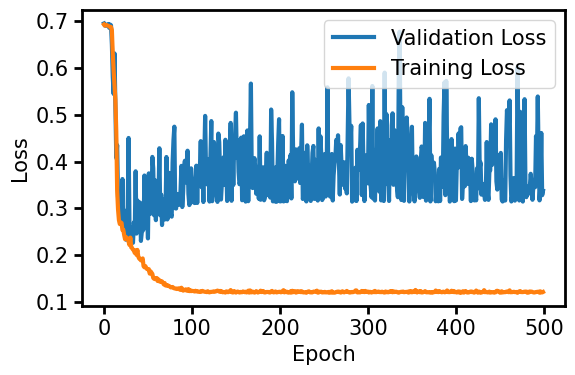

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(val_loss_curve, label='Validation Loss')
ax.plot(train_loss_curve, label='Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(loc='upper right')
fig.tight_layout()

Report the AUC on test data.


In [14]:
for index, batch in enumerate(test_loader):
      # Your batch returns a X, y stacked in a batch
      X_batch, y_batch = batch[0], batch[1]
      print(X_batch.shape, y_batch.shape)
print()

torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([256, 101, 4]) torch.Size([256])
torch.Size([21, 101, 4]) torch.Size([21])



In [15]:
################ Code #################
from sklearn.metrics import roc_auc_score

eval_predictions = evaluate(model, test_loader, device="cuda:0")
print(len(eval_predictions[0]))

################ Code #################

Batch 0 completed.
Batch 1 completed.
Batch 2 completed.
Batch 3 completed.
Batch 4 completed.
Batch 5 completed.
Batch 6 completed.
Batch 7 completed.
Batch 8 completed.
Batch 9 completed.
Batch 10 completed.
2581


In [16]:
## Convert tensors into numpy arrays
eval_labels_np = eval_predictions[0]
eval_predictions_np = eval_predictions[1]
score = roc_auc_score(eval_labels_np, eval_predictions_np)
print(f"The AUC/ROC score for the fully trained model is: {score}")

The AUC/ROC score for the fully trained model is: 0.9470096695622082


## Problem 2: Image Segmentation

### 2.1 (20 points) Build Datasets and DataLoaders

Parse data from image filepaths.

In [17]:
paths = [path for path in glob.glob("cell_segmentation/*") if "cells" in path]

def load_img(path):
    x = np.array(Image.open(path)) / 255
    y = np.array(Image.open(path.replace("cells","masks"))) / 255
    return x, y

Load one image.


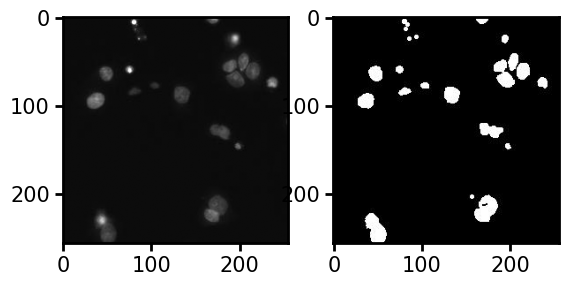

In [18]:
idx = 20
cells, masks = load_img(paths[idx])
fig, axes = plt.subplots(1,2)
axes[0].imshow(cells, cmap='gray')
axes[1].imshow(masks, cmap='gray')

Your ImageDataset class.

In [19]:
################ Code #################
class ImageDataset(Dataset):
  def __init__(self, paths):
    self.paths = paths
    return

  def __getitem__(self, index):
    path = self.paths[index]
    cell, mask = load_img(path)
    t_cell = transforms.ToTensor()(cell).to(torch.float32)
    t_mask = transforms.ToTensor()(mask).to(torch.float32)
    return t_cell, t_mask

  def __len__(self):
    return len(self.paths)


Split your data and load your DataLoaders.


In [20]:
################ Code #################
suptrain_paths, test_paths = train_test_split(paths, test_size=0.2, random_state=0)
train_paths, val_paths = train_test_split(suptrain_paths, test_size=0.125, random_state=0)

train_data = ImageDataset(train_paths)
test_data = ImageDataset(test_paths)
val_data = ImageDataset(val_paths)

batch_size = 4
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

In [21]:
# Check data shapes
for loader in [train_dataloader, val_dataloader, test_dataloader]:
    for index, batch in enumerate(loader):
        # Your batch returns a X, y stacked in a batch
        X_batch, y_batch = batch[0], batch[1]
        print(X_batch.shape, y_batch.shape)
    print()

torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4, 1, 256, 256]) torch.Size([4, 1, 256, 256])
torch.Size([4,


Is it necessary to apply random translation to your images? Briefly justify your answer.


## 2.1 Rotational Invariance
No, it is not necessary to apply random rotational transformations to our training samples in cell segmentation. For these data, and for most types of cell culture data, each image contains a high number of cells in a variety of rotational states ("poses"), thus already representing a wide variety of rotational states which the augmentation would attempt to generate. Therefore, any rotational variation is already present in the original, unaugmented data.

## 2.2 Translational Invariance/Equivariance
Traditional CNNs possess translational equivariance because the learnable weights of each kernel (filter) in the model are shared across the entire image. This means that certain image localities representing (one object position) cannot be given higher weight than another, which results in many of the same behaviors associated with true translational invariance. Although the architecture of CNNs are not truly translationally invariant, CNNs can approximate translational invariance by pooling values within overlapping kernels (provided by striding). This means that if the translational shift is smaller than, or at least similar to, the stride length, then most of the same kernel values will be pooled in the convolution, thus enabling the CNN to detect an object at different translations.

In [22]:
############### Answer #################

### 2.2 (20 points) Train a U-Net Model that Performs Image Segmentation

Implement Dice loss.

In [23]:
def dice_loss(pred, target):
    """Calculate Dice loss.

    Parameters
    ----------
        pred:
            predictions from the model
        target:
            ground truth label
    """
    #print(f"Predictions: {type(pred)}")
    #print(f"Targets: {type(target)}")
    num = 2 * ((pred * target).sum()) + 1
    denom = pred.sum() + target.sum() + 1
    return 1 - (num/denom)

################ Code #################

The U-Net Model.


In [24]:
class DownSampling(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, name=None):
        super(DownSampling, self).__init__()

        self.conv = ConvBlock(in_channels, out_channels, kernel_size)
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):

        conv_out = self.conv(x)
        output = self.max_pool(conv_out)

        return output, conv_out


class UpSampling(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, name=None):
        super(UpSampling, self).__init__()

        self.conv = ConvBlock(in_channels, out_channels, kernel_size)
        self.conv_t = nn.ConvTranspose2d(out_channels, out_channels, kernel_size, \
                                         padding=1, stride=2, output_padding=1)


    def forward(self, x, skip):

        conv_out = self.conv(x)
        output = self.conv_t(conv_out)

        output += skip

        return output


class ConvBlock(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size, padding=1, stride=1, name=None):
        super(ConvBlock, self).__init__()

        block = []
        # first conv layer
        block.append(nn.Conv2d(in_channels, out_channels, kernel_size, \
                               padding=padding, stride=stride))
        block.append(nn.ReLU())
        block.append(nn.BatchNorm2d(out_channels))

        # second conv layer
        block.append(nn.Conv2d(out_channels, out_channels, kernel_size, \
                               padding=padding, stride=stride))
        block.append(nn.ReLU())
        block.append(nn.BatchNorm2d(out_channels))

        # make sequential
        self.conv_block = nn.Sequential(*block)


    def forward(self, x):

        output = self.conv_block(x)

        return output


class UNet(nn.Module):

    def __init__(self, num_kernel=8, kernel_size=3, dim=1, target_dim=1):
        """UNet

        Arguments:
            num_kernel: int
                number of kernels to use for the first layer
            kernel_size: int
                size of the kernel for the first layer
            dims: int
                number of color channels for input images
            target_dim: int
                number of channels for the output mask
        """

        super(UNet, self).__init__()

        self.num_kernel = num_kernel
        self.kernel_size = kernel_size
        self.dim = dim
        self.target_dim = 1

        # encode
        self.encode_1 = DownSampling(self.dim, num_kernel, kernel_size)
        self.encode_2 = DownSampling(num_kernel, num_kernel*2, kernel_size)
        self.encode_3 = DownSampling(num_kernel*2, num_kernel*4, kernel_size)
        self.encode_4 = DownSampling(num_kernel*4, num_kernel*8, kernel_size)

        # bridge
        self.bridge = nn.Conv2d(num_kernel*8, num_kernel*16, kernel_size, padding=1, stride=1)

        # decode
        self.decode_4 = UpSampling(num_kernel*16, num_kernel*8, kernel_size)
        self.decode_3 = UpSampling(num_kernel*8, num_kernel*4, kernel_size)
        self.decode_2 = UpSampling(num_kernel*4, num_kernel*2, kernel_size)
        self.decode_1 = UpSampling(num_kernel*2, num_kernel, kernel_size)

        self.segment = nn.Conv2d(num_kernel, self.target_dim, 1, padding=0, stride=1)
        self.activate = nn.Sigmoid()


    def forward(self, x):

        has_channel = x.ndim == 4
        if not has_channel:
            x = x.unsqueeze(1)

        x, skip_1 = self.encode_1(x)
        x, skip_2 = self.encode_2(x)
        x, skip_3 = self.encode_3(x)
        x, skip_4 = self.encode_4(x)

        x = self.bridge(x)

        x = self.decode_4(x, skip_4)
        x = self.decode_3(x, skip_3)
        x = self.decode_2(x, skip_2)
        x = self.decode_1(x, skip_1)

        x = self.segment(x)

        pred = self.activate(x)

        if not has_channel:
            pred = pred.squeeze(1)

        return pred


    def args_dict(self):
        """model arguments to be saved
        """

        model_args = {'dim': self.dim,
                      'target_dim': self.target_dim,
                      'num_kernel' : self.num_kernel,
                      'kernel_size' : self.kernel_size}

        return model_args

Example model usage.

In [25]:
model = UNet()
y = model(torch.randn(4, 256, 256))

print(y.shape)

torch.Size([4, 256, 256])


A function to plot a segmentation map.


In [26]:
def plot_seg(img, pred_seg, true_seg, mask_cutoff=0.5):

    """ Visualize segmentation results.
    Inputs:
        image: orginal image, shape: 256 x 256
        pred_seg: predicted mask, shape: 256 x 256
        true_seg: true mask, shape: 256 x 256
        mask_cutoff: if the mask values is larger than mask_cutoff, the mask will appear on the image
    """
    img = img.squeeze()
    pred_seg = pred_seg.squeeze()
    true_seg = true_seg.squeeze()

    fig, ax = plt.subplots(1, 3, sharex='col', sharey='row')
    fig.set_size_inches((15,15))

    ax[0].set_title("Original Image")
    ax[1].set_title("Prediction")
    ax[2].set_title("Ground Truth")

    img = np.stack([img,img,img],axis = -1)
    ax[0].imshow(img)
    ax[1].imshow(np.clip(color.label2rgb(pred_seg > mask_cutoff,img,colors=[(255,0,0)],alpha=0.0025, bg_label=0, bg_color=None),0,1))
    ax[2].imshow(np.clip(color.label2rgb(true_seg > mask_cutoff,img,colors=[(255,0,0)],alpha=0.0025, bg_label=0, bg_color=None),0,1))

    plt.show()

Train your model.

Show segmentation results for 3 images from the test dataset.


In [27]:
def train(model, dataloader, optimizer, device):

    '''
    A function to train on the entire dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the train data
        optimizer (torch.optim.Optimizer): Optimizer object to interface gradient calculation and optimization
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    batch_loss = []
    model.train() # Set model to training mode

    for batch in dataloader:
        cells, true_masks = batch
        #print(f"\nCell Shape: {cells.shape} and type: {type(cells[0])}")
        #print(f"Mask Shape: {true_masks.shape} and type: {type(true_masks[0])}")
        cells = cells.to(device)
        true_masks = true_masks.to(device)

        ## Make prediction, find loss
        pred_mask = model(cells)
        loss = dice_loss(pred_mask, true_masks)
        batch_loss.append(loss.item()) # Record loss

        ## Update parameters with Adam
        print(loss)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    mean_loss = sum(batch_loss) / len(batch_loss)

    return mean_loss


def validate(model, dataloader, lossfn, device):

    '''
    A function to validate on the validation dataset for one epoch.

    Args:
        model (torch.nn.Module): Your sequence classifier
        dataloader (torch.utils.data.Dataloader): DataLoader object for the validation data
        device (str): Your device

    Returns:
        float: loss averaged over all the batches

    '''

    batch_loss = []
    model.eval() # Set model to training mode

    for batch in dataloader:
        cells, true_masks = batch
        cells = cells.to(device)
        true_masks = true_masks.to(device)

        ## Make prediction, find loss
        pred_mask = model(cells)
        pred_mask_np = pred_mask.cpu().detach().numpy()
        true_mask_np = true_masks.cpu().detach().numpy()
        loss = lossfn(pred_mask_np, true_mask_np)
        batch_loss.append(loss.item()) # Record loss

    mean_loss = sum(batch_loss) / len(batch_loss)
    return mean_loss

In [28]:
device = 'cuda:0'
model = UNet().to(device)

optimizer = torch.optim.Adam(list(model.parameters()), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', verbose=True, factor=0.5)

val_loss_curve = []
train_loss_curve = []

# Use tqdm for progress bar
epochs = 20
tqdm_progress =  tqdm(range(epochs), desc="Progress")

for epoch in tqdm_progress:
    # Compute train your model on training data
    epoch_loss = train(model, train_dataloader, optimizer, device=device)

    # Validate your on validation data
    val_loss = validate(model, val_dataloader, dice_loss, device=device)

    # Record train and loss performance
    train_loss_curve.append(epoch_loss)
    val_loss_curve.append(val_loss)

    # The learning rate scheduler record the validation loss
    scheduler.step(val_loss)
    tqdm_progress.set_postfix(train_loss=f'{epoch_loss:.3f}', val_loss=f'{val_loss:.3f}', refresh=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
Progress:   0%|          | 0/20 [00:00<?, ?it/s]

tensor(0.8911, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.8613, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.6957, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.9352, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.8982, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7950, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.8424, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7445, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5855, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7475, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.8986, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7442, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.8140, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7073, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.8334, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7085, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.8111, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7364, device='cuda:0',

Progress:   5%|▌         | 1/20 [00:02<00:49,  2.63s/it, train_loss=0.723, val_loss=0.653]

tensor(0.5529, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.6414, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5394, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5622, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5174, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.4543, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5386, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.6540, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.6201, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.4539, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7144, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.4860, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5939, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.3337, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5958, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.5666, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.6525, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.7076, device='cuda:0',

Progress:   5%|▌         | 1/20 [00:03<00:49,  2.63s/it, train_loss=0.505, val_loss=0.333]

...

tensor(0.1166, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1321, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1149, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1328, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0926, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1135, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1282, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1441, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0849, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1569, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0926, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1622, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1594, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1193, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1302, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0946, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0871, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1317, device='cuda:0',

Progress:  95%|█████████▌| 19/20 [00:23<00:01,  1.16s/it, train_loss=0.116, val_loss=0.113]

tensor(0.1545, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0781, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1016, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1795, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1655, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0651, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1347, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1344, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0881, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1240, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1092, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1415, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1061, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0755, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1124, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1198, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1198, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.0897, device='cuda:0',

Progress: 100%|██████████| 20/20 [00:24<00:00,  1.23s/it, train_loss=0.113, val_loss=0.104]

tensor(0.1607, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1412, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1445, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1216, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1018, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1079, device='cuda:0', grad_fn=<RsubBackward1>)
tensor(0.1147, device='cuda:0', grad_fn=<RsubBackward1>)


In [29]:
################ Code #################
# Make 3 random choices
indys = np.random.choice(len(test_data), 3, replace=False)

In [30]:
def plot_segs(indys):
  for i in indys:
    cells = test_data[i][0]
    masks = test_data[i][1].numpy()
    pred_mask = model(cells.to(device)).cpu().detach().numpy()
    plot_seg(cells.numpy(), pred_mask, masks)
  return

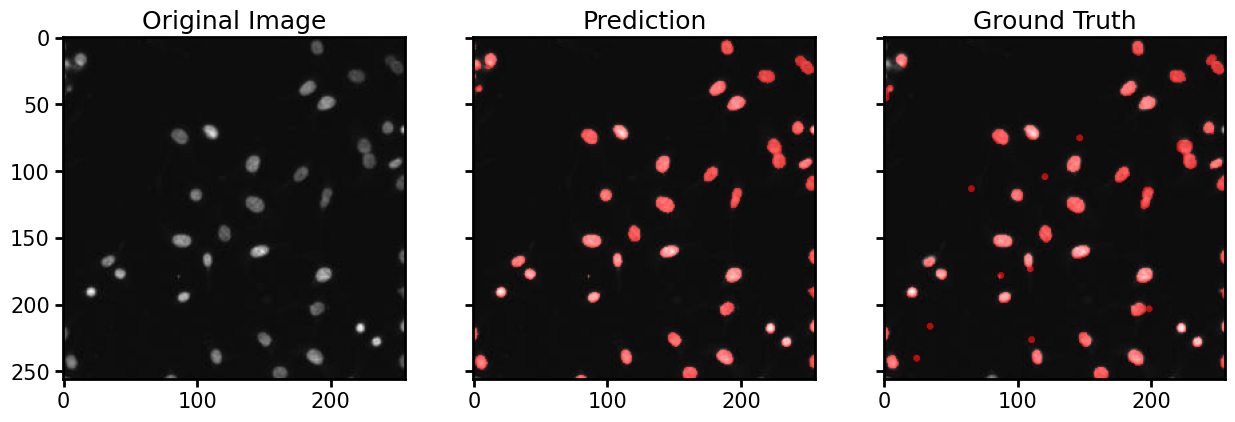

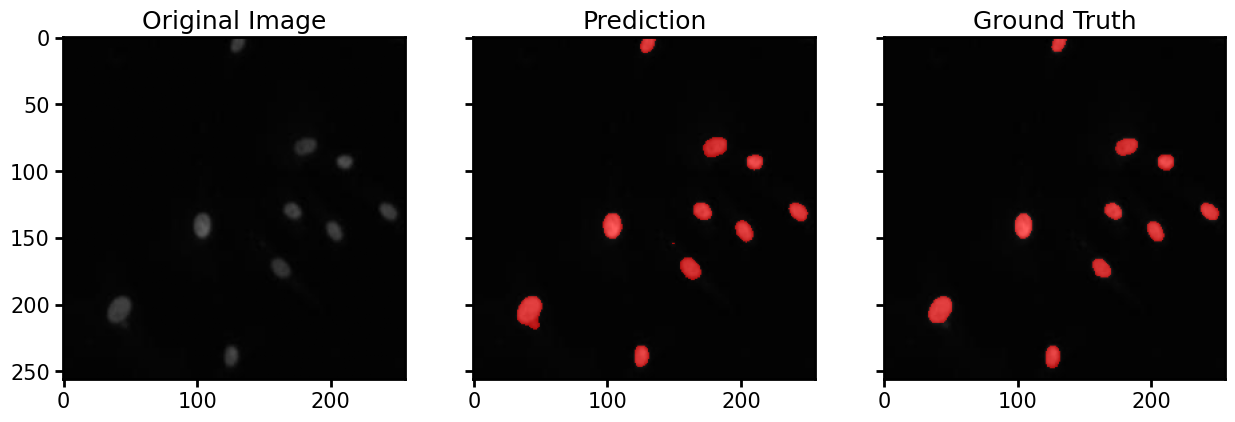

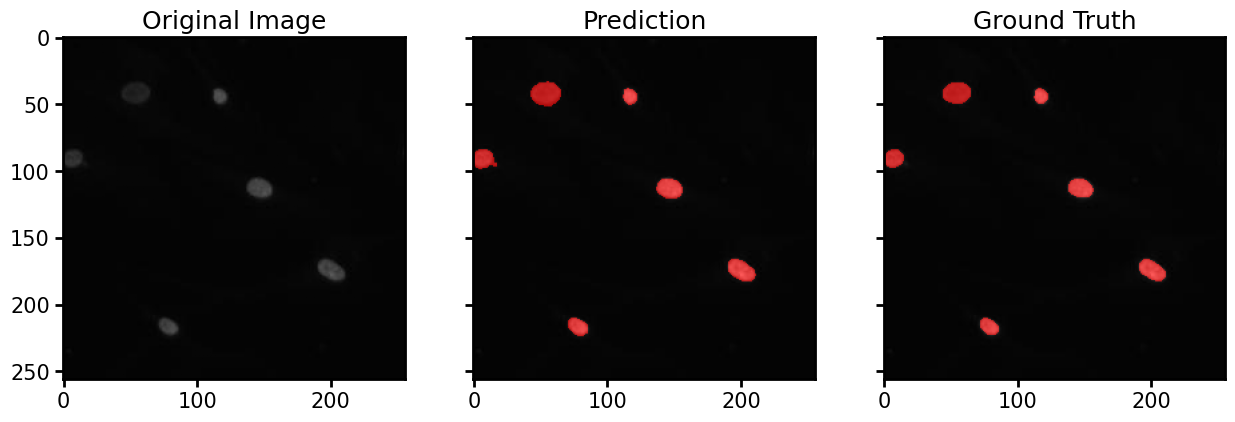

In [31]:
plot_segs(indys)